In [132]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.xmargin": 0,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": True,
})

# mpl.rcParams.update({
#     "figure.figsize": (6, 4),
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.facecolor": "#fafafa",
#     "axes.grid": True,
#     "grid.color": "#dddddd",
#     "grid.linestyle": "--",
#     "axes.prop_cycle": mpl.cycler(color=["#4C72B0", "#55A868", "#C44E52",
#                                          "#8172B2", "#CCB974", "#64B5CD"]),
#     "font.size": 11,
#     "axes.labelsize": 12,
#     "axes.titlesize": 14,
#     "legend.frameon": True,
#     "legend.facecolor": "white",
#     "legend.edgecolor": "#dddddd",
#     "lines.linewidth": 2,
# })

from plt_utils import plot, savefig

import os

task_name, data_name, default_window, default_token_dim = "assoc_recall", "data_100_30", 20, 6
# task_name, data_name, default_window, default_token_dim = "assoc_recall_mk", "data_100_6", 100, 12
# task_name, data_name, default_window, default_token_dim = "var_copy", "data_100_5_30", 20, 12
# task_name, data_name, default_window, default_token_dim = "binary_recall_mix", "data_100_4", 100, 12

In [134]:
dashed_task_name = '-'.join(task_name.split('_'))

all_losses = {}
all_accs = {}
all_params = {}

In [135]:
for run_name in os.listdir("results/" + task_name + "/" + data_name):
    if len(run_name.split("_")) != 10: continue

    for run in os.listdir("results/" + task_name + "/" + data_name + "/" + run_name):
        if run.startswith("."):
            continue
        
        # print("results/" + task_name + "/" + data_name + "/" + run_name + "/" + run)
        data = torch.load("results/" + task_name + "/" + data_name + "/" + run_name + "/" + run, weights_only=False)
        losses = data["losses"]
        accs = data["accs"]
        # args = data["args"]
        params = data["param_count"]

        if run_name not in all_losses.keys():
            all_losses[run_name] = losses.unsqueeze(0)
            all_accs[run_name] = accs.unsqueeze(0)
            all_params[run_name] = params
        else:
            all_accs[run_name] = torch.cat((all_accs[run_name], accs.unsqueeze(0)))
            all_losses[run_name] = torch.cat((all_losses[run_name], losses.unsqueeze(0)))

for run_name in all_losses.keys():
    all_losses[run_name] = all_losses[run_name].detach().numpy()
    all_accs[run_name] = all_accs[run_name].detach().numpy()

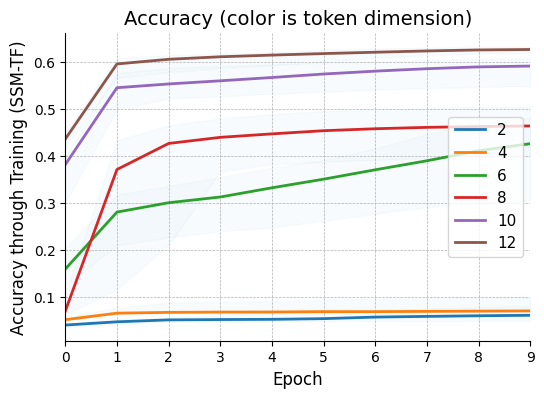

In [136]:
params = {}
params['layer1'] = 'SSM'
params['layer2'] = 'TF'
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'epochs', 'dim', x_axis='epochs')
plt.ylabel("Accuracy through Training (SSM-TF)")
plt.xlabel("Epoch")
plt.title("Accuracy (color is token dimension)")
savefig(task_name, name)

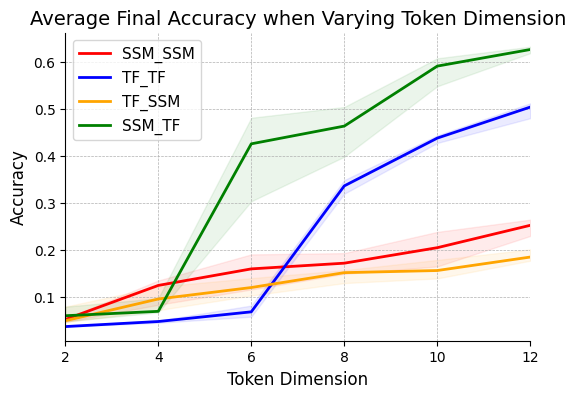

In [137]:
params = {}
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'dim', 'layers')
plt.title("Average Final Accuracy when Varying Token Dimension")
plt.xlabel("Token Dimension")
plt.ylabel("Accuracy")
savefig(task_name, name)

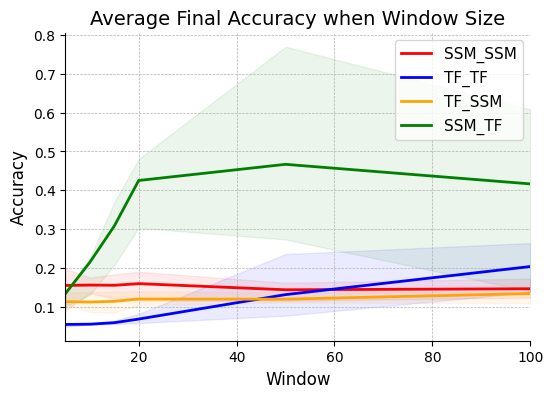

In [138]:
params = {}
params['window'] = None
params['dim'] = default_token_dim
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'window', 'layers')
plt.title("Average Final Accuracy when Window Size")
plt.xlabel("Window")
plt.ylabel("Accuracy")
savefig(task_name, name)

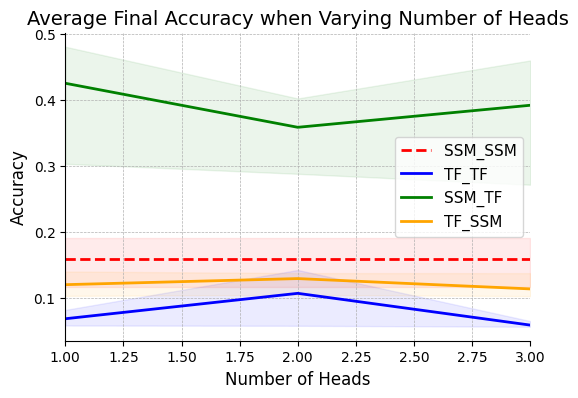

In [139]:
params = {}
params['window'] = default_window
params['dim'] = default_token_dim
params['num_heads'] = None
params['state_dim'] = 1

name = plot(all_accs, params, 'num_heads', 'layers')
plt.title("Average Final Accuracy when Varying Number of Heads")
plt.xlabel("Number of Heads")
plt.ylabel("Accuracy")
savefig(task_name, name)

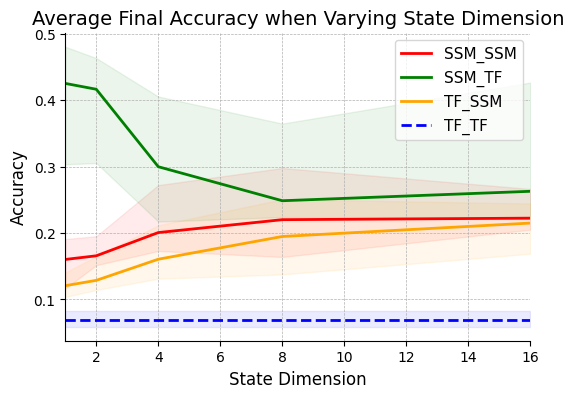

In [140]:
params = {}
params['window'] = default_window
params['dim'] = default_token_dim
params['num_heads'] = 1
params['state_dim'] = None

name = plot(all_accs, params, 'state_dim', 'layers')
plt.title("Average Final Accuracy when Varying State Dimension")
plt.xlabel("State Dimension")
plt.ylabel("Accuracy")
savefig(task_name, name)

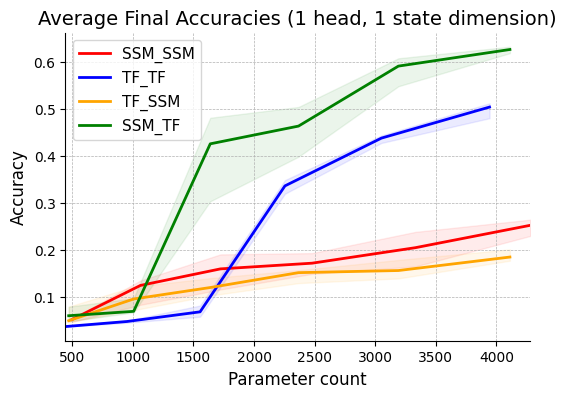

In [141]:
params = {}
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'dim', 'layers', param_counts=all_params, x_axis='params')
plt.title("Average Final Accuracies (1 head, 1 state dimension)")
plt.xlabel("Parameter count")
plt.ylabel("Accuracy")
savefig(task_name, name)

In [142]:
# params = {}
# params['window'] = None
# params['dim'] = 20
# params['num_heads'] = 1
# params['state_dim'] = 1

# name = plot(all_accs, params, 'window', 'layers', param_counts=all_params, x_axis='params')
# plt.title("Average Final Accuracies (dim 20, 1 head, 1 state dimension)")
# plt.xlabel("Parameter count")
# plt.ylabel("Accuracy")
# savefig(task_name, name)